In [10]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import yfinance as yf

In [11]:
nu = yf.Ticker("NU")
nu.info

{'address1': 'Rua Capote Valente, 39',
 'city': 'São Paulo',
 'state': 'SP',
 'zip': '05409-000',
 'country': 'Brazil',
 'website': 'https://www.nubank.com.br',
 'industry': 'Banks - Regional',
 'industryKey': 'banks-regional',
 'industryDisp': 'Banks - Regional',
 'sector': 'Financial Services',
 'sectorKey': 'financial-services',
 'sectorDisp': 'Financial Services',
 'longBusinessSummary': 'Nu Holdings Ltd. provides digital banking platform in Brazil, Mexico, Colombia, Cayman Islands, Germany, Argentina, the United States, and Uruguay. It offers spending solutions comprising Nu credit and prepaid card, a digitally enabled card that acts as a credit and a prepaid card; Ultraviolet credit and prepaid card, a premium metal credit card for affluent customers; mobile payment solutions for NuAccount customers to make and receive transfers, pay bills, and make everyday purchases through their mobile phones; and Nu Shopping, an integrated mall that enables customers to purchase goods and ser

In [12]:
data = nu.history(start = '2021-12-13', end = '2024-10-18')  # '%Y-%m-%d'
data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2021-12-13 00:00:00-05:00,11.100,11.29,10.31,10.81,19658400,0.0,0.0
2021-12-14 00:00:00-05:00,10.550,10.58,9.27,9.92,22728100,0.0,0.0
2021-12-15 00:00:00-05:00,9.630,10.29,9.42,10.01,12663900,0.0,0.0
2021-12-16 00:00:00-05:00,10.450,10.49,9.56,10.00,13981300,0.0,0.0
2021-12-17 00:00:00-05:00,9.925,10.17,9.14,9.80,21560800,0.0,0.0


In [19]:
data.index

DatetimeIndex(['2021-12-13 00:00:00-05:00', '2021-12-14 00:00:00-05:00',
               '2021-12-15 00:00:00-05:00', '2021-12-16 00:00:00-05:00',
               '2021-12-17 00:00:00-05:00', '2021-12-20 00:00:00-05:00',
               '2021-12-21 00:00:00-05:00', '2021-12-22 00:00:00-05:00',
               '2021-12-23 00:00:00-05:00', '2021-12-27 00:00:00-05:00',
               ...
               '2024-10-04 00:00:00-04:00', '2024-10-07 00:00:00-04:00',
               '2024-10-08 00:00:00-04:00', '2024-10-09 00:00:00-04:00',
               '2024-10-10 00:00:00-04:00', '2024-10-11 00:00:00-04:00',
               '2024-10-14 00:00:00-04:00', '2024-10-15 00:00:00-04:00',
               '2024-10-16 00:00:00-04:00', '2024-10-17 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=716, freq=None)

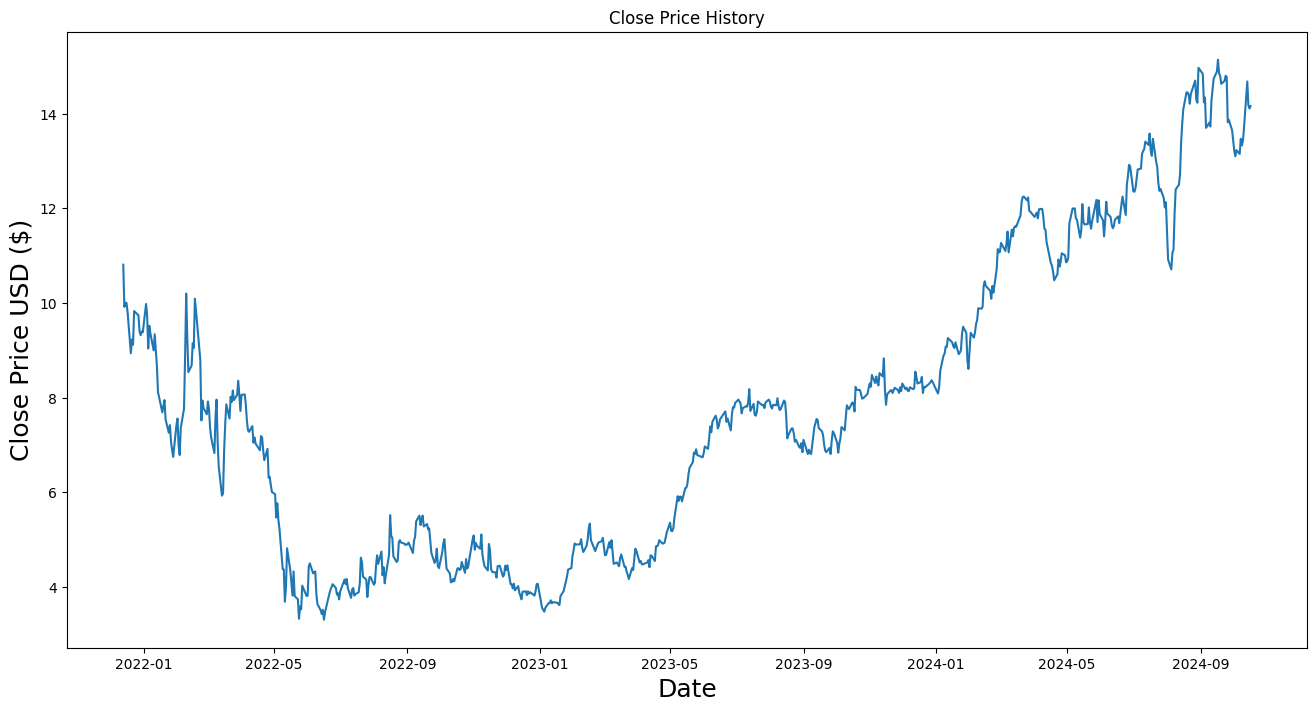

In [13]:
# Plotting close price
plt.figure(figsize=(16,8))
plt.plot(data['Close'])
plt.title('Close Price History')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()


In [18]:
# deleting dividends and stock splits
data = data.drop(['Dividends', 'Stock Splits'], axis=1)
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2021-12-13 00:00:00-05:00,11.100,11.29,10.31,10.81,19658400
2021-12-14 00:00:00-05:00,10.550,10.58,9.27,9.92,22728100
2021-12-15 00:00:00-05:00,9.630,10.29,9.42,10.01,12663900
2021-12-16 00:00:00-05:00,10.450,10.49,9.56,10.00,13981300
2021-12-17 00:00:00-05:00,9.925,10.17,9.14,9.80,21560800


Price es el precio de cierre de Nu holds para ese dia

In [20]:
data['Tomorrow'] = data['Close'].shift(-1)
data = data.dropna()
data.head()

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
2021-12-13 00:00:00-05:00,11.100,11.29,10.31,10.81,19658400,9.92
2021-12-14 00:00:00-05:00,10.550,10.58,9.27,9.92,22728100,10.01
2021-12-15 00:00:00-05:00,9.630,10.29,9.42,10.01,12663900,10.00
2021-12-16 00:00:00-05:00,10.450,10.49,9.56,10.00,13981300,9.80
2021-12-17 00:00:00-05:00,9.925,10.17,9.14,9.80,21560800,8.94


In [21]:
data['Target'] = (data['Tomorrow'] > data['Close']).astype(int)
# Look if tomorrow's price is higher than today's price
data.head()

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
2021-12-13 00:00:00-05:00,11.100,11.29,10.31,10.81,19658400,9.92,0
2021-12-14 00:00:00-05:00,10.550,10.58,9.27,9.92,22728100,10.01,1
2021-12-15 00:00:00-05:00,9.630,10.29,9.42,10.01,12663900,10.00,0
2021-12-16 00:00:00-05:00,10.450,10.49,9.56,10.00,13981300,9.80,0
2021-12-17 00:00:00-05:00,9.925,10.17,9.14,9.80,21560800,8.94,0


# Training